## P2.c — LSH mes a mes: pares ≥ 90%

- **Entrada:** `data/final/` + `data/p2/firmas/`
- **Salida:** `data/p2/pares/` — pares de la misma entidad, ≤ 15 días, Jaccard exacto ≥ 0.90
- Por cada mes: carga mes + mes siguiente (pruning) → bandas LSH → candidatos → verificación exacta → parquet. El proceso 1 del par es el más antiguo y está en el mes de análisis, así ningún par se repite entre meses

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes y funciones compartidas (`02_P2/p2_funciones.ipynb`)

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
ruta_funciones = str(proyecto / "02_P2" / "p2_funciones.ipynb")
%run $ruta_funciones

final_dir     = proyecto / "data" / "final"
firmas_dir    = proyecto / "data" / "p2" / "firmas"
pares_dir     = proyecto / "data" / "p2" / "pares"
entidades_dir = proyecto / "data" / "p2" / "entidades"

/opt/conda/lib/python3.11/site-packages/nbformat/__init__.py:93: MissingIDFieldWarning: Code cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


- Spark

In [3]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("p2_c_lsh_pares")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [4]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 3.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga

In [5]:
assert firmas_dir.exists(), f"No se encuentra {firmas_dir}; corre a_firmas_minhash.ipynb"
procesos = spark.read.parquet(str(final_dir)).select(*COLS_P2)
firmas   = spark.read.parquet(str(firmas_dir))
N = procesos.count()

meses = [(r_["anio"], r_["mes"]) for r_ in procesos.select("anio", "mes").distinct().orderBy("anio", "mes").collect()]
print(f"{N:,} procesos | {len(meses)} meses: {meses[0]} → {meses[-1]}")

231,171 procesos | 36 meses: (2023, 1) → (2025, 12)


### 2. Un mes

In [6]:
def procesar_mes(anio, mes):
    proc_m   = procesos.where(filtro_meses(anio, mes))
    firmas_m = firmas.where(filtro_meses(anio, mes))
    cands    = candidatos_lsh(lsh_bandas(firmas_m), anio, mes)
    return verificar_pares(cands, proc_m, firmas_m), cands

### 3. Corrida completa → `data/p2/pares/`

In [7]:
REINICIAR = False          # True para borrar data/p2/pares y empezar de cero
if REINICIAR and pares_dir.exists():
    shutil.rmtree(pares_dir)

hechos = {(int(p.parent.name.split("=")[1]), int(p.name.split("=")[1])) for p in pares_dir.glob("anio=/mes=")} if pares_dir.exists() else set()
print(f"Meses ya procesados: {len(hechos)} de {len(meses)}")

t_total = time.time()
for anio, mes in meses:
    if (anio, mes) in hechos:
        continue
    t0 = time.time()
    pares_m, cands_m = procesar_mes(anio, mes)
    cands_m = cands_m.cache(); n_c = cands_m.count()
    pares_m = pares_m.cache(); n_p = pares_m.count()
    pares_m.withColumn("anio", F.lit(anio)).withColumn("mes", F.lit(mes)).write.mode("append").partitionBy("anio", "mes").parquet(str(pares_dir))
    cands_m.unpersist(); pares_m.unpersist()
    print(f"{anio}-{mes:02d}: {n_c:6,} candidatos → {n_p:5,} pares ≥ {UMBRAL}  ({time.time() - t0:5.1f} s)")
print(f"Total: {time.time() - t_total:,.0f} s")

Meses ya procesados: 0 de 36
2023-01:     64 candidatos →    33 pares ≥ 0.9  ( 12.9 s)
2023-02:    449 candidatos →   164 pares ≥ 0.9  (  8.5 s)
2023-03:  3,142 candidatos → 2,207 pares ≥ 0.9  ( 13.4 s)
2023-04:  1,295 candidatos →   405 pares ≥ 0.9  (  7.6 s)
2023-05:  3,380 candidatos → 2,455 pares ≥ 0.9  (  8.3 s)
2023-06:  1,425 candidatos →   496 pares ≥ 0.9  (  7.3 s)
2023-07:    874 candidatos →   393 pares ≥ 0.9  (  6.9 s)
2023-08:  1,192 candidatos →   509 pares ≥ 0.9  (  8.6 s)
2023-09:  1,210 candidatos →   444 pares ≥ 0.9  (  6.9 s)
2023-10:  1,638 candidatos →   572 pares ≥ 0.9  (  6.5 s)
2023-11:  1,525 candidatos →   580 pares ≥ 0.9  (  6.8 s)
2023-12:  4,243 candidatos → 3,183 pares ≥ 0.9  (  7.1 s)
2024-01:    229 candidatos →   138 pares ≥ 0.9  (  5.4 s)
2024-02:  1,271 candidatos →   536 pares ≥ 0.9  (  6.5 s)
2024-03:  1,594 candidatos →   760 pares ≥ 0.9  (  6.0 s)
2024-04:  2,006 candidatos →   872 pares ≥ 0.9  (  6.2 s)
2024-05:  1,953 candidatos →   930 pares ≥ 

### 4. Checkpoint: parquet de pares

In [8]:
pares = spark.read.parquet(str(pares_dir))
n_pares = pares.count()
resumen = pares.groupBy("anio", "mes").count().orderBy("anio", "mes").toPandas().rename(columns={"count": "pares_90"})
assert len(resumen) == len(meses), f"Faltan meses: {set(meses) - set(zip(resumen.anio, resumen.mes))}"
assert pares.where((F.col("jaccard") < UMBRAL) | (F.col("dias_diferencia") > VENTANA_DIAS) | (F.col("dias_diferencia") < 0)).count() == 0
print(f"Pares guardados: {n_pares:,} | {len(resumen)} meses | {len(pares.columns)} columnas")
pares.printSchema()

Pares guardados: 141,935 | 36 meses | 29 columnas
root
 |-- ocid_1: string (nullable = true)
 |-- ocid_2: string (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- periodo: string (nullable = true)
 |-- fecha_1: timestamp (nullable = true)
 |-- fecha_2: timestamp (nullable = true)
 |-- dias_diferencia: integer (nullable = true)
 |-- jaccard: double (nullable = true)
 |-- minhash_sim: double (nullable = true)
 |-- monto_final_1: double (nullable = true)
 |-- monto_final_2: double (nullable = true)
 |-- monto_suma: double (nullable = true)
 |-- tramo_1: string (nullable = true)
 |-- tramo_2: string (nullable = true)
 |-- tramo_suma: string (nullable = true)
 |-- metodo_1: string (nullable = true)
 |-- metodo_2: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- proveedor_1: string (nullable = true)
 |-- proveedor_2: string (nullable = true)
 |-- n_postores_1: integer (nullable = true)
 |-- n_postores_2: integer (nullabl

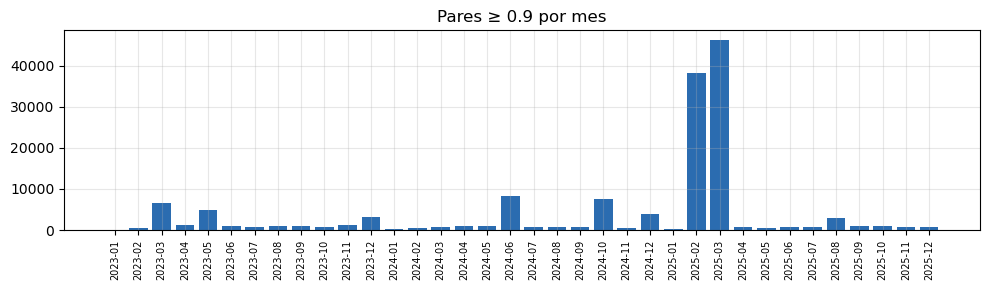

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
x = resumen["anio"].astype(str) + "-" + resumen["mes"].astype(str).str.zfill(2)
ax.bar(x, resumen["pares_90"], color="#2b6cb0"); ax.set_title(f"Pares ≥ {UMBRAL} por mes"); ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); plt.show()

- Siguiente: `d_entidades_rate.ipynb`

### 5. Cierre

In [10]:
spark.stop()